In [1]:
# Zachary Katz
# zachary_katz@mines.edu
# 14 March 2026

"""
Overview Figure for David Glacier Subglacial Hydrology Radar Specularity Paper

Map of David Glacier [MOA, Velocity] with insets for radar lines, seismic, ICESat-2/CryoSat-2 outlines, and DDInSAR outlines.
"""

# Imports
import shapefile
import shapely
from pyproj import CRS, Transformer
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import geopandas as gpd
import cmasher as cmr
import xarray as xr
import rasterio
import numpy as np
from cmap import Colormap
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import os
import matplotlib.colors as colors
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# User-defined paths
offset_video_path_1617 = '../_Data/UTG_1617_OffsetVideo'
offset_video_path_1819 = '../_Data/UTG_1819_OffsetVideo'
vel_path = '/mnt/c/users/ZacharyKatz/Desktop/Research/Background/antarctica_ice_velocity_450m_v2.nc' # Path to velocity field
moa_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/moa750_2009_hp1_v1.1.tif' # Path to MOA
sld_path = '../_Data/Ju_SLD2'
seismic_path = '../_Data/Ju_Seismic/SeismicKSS2_21-22.csv'
evolving_path = '../_Data/Sauthoff_EvolvingOutlines'
DDInSAR_path = '../_Data/Kim_DDInSAR'
# RINGS Grounding Line Paths
rings_grounded_path = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_coastline_path = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_coastline_2022.shp'
rings_grounded_path = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_iceshelves_path = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_iceshelves_2022.shp'
rings_islands_ADD = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_islands_ADD.shp'
rings_polygonmask = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_polygonmask.shp'

# Functions
def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y


In [2]:
# Load grounding lines
paths = [
    rings_coastline_path,
    rings_grounded_path,
    rings_iceshelves_path,
    rings_islands_ADD,
    rings_polygonmask,
]

records_full = []
shapes_full = []
field_names_full = []

for path in paths:
    sf = shapefile.Reader(path)
    records_full.append(sf.records())
    shapes_full.append(sf.shapes())
    field_names_full.append([f[0] for f in sf.fields[1:]])

ice_shelf_polygons = []
grounded_polygons = []

sf = shapefile.Reader(rings_iceshelves_path)
fields = sf.fields[1:]  # Skip deletion flag
field_names = [field[0] for field in fields]

records = sf.records()
shapes = sf.shapes()

for record, shape in zip(records, shapes):
    rec_dict = dict(zip(field_names, record))
    classification = rec_dict["Type"]
    points = shape.points
    parts = list(shape.parts)
    parts.append(len(points))  # Append the end index of the last part
    for i in range(len(parts) - 1):
        part = points[parts[i] : parts[i + 1]]
        polygon = shapely.Polygon(part)
        if (
            classification == "Isolated island"
            or classification == "Ice rise or connected island"
            or classification == "Grounded ice or land"
        ):
            if polygon.is_valid:
                grounded_polygons.append(polygon)
        elif classification == "Ice shelf":
            if polygon.is_valid:
                ice_shelf_polygons.append(polygon)
        else:
            print(f"Unknown classification: {classification}")

def plot_RINGS_shapefile(
    records_list: list[shapefile._Record],
    shapes_list: list[shapefile.Shape],
    field_names_list: list[str],
    ax ,
    colors: list[str],
    transform,
    fill: bool = False,
    zorder: int = 2,
    linewidth: int = 2,
) -> None:
    """
    Plots the given records and shapes on axis ax.

    Example usage:
    
    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
        transform=ps71_projection, fill=True, zorder=2, linewidth=1)

    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
        transform=ps71_projection, fill=False, zorder=2, linewidth=1)

    Parameters
    ----------
    records : list[shapefile._Record]
        Shapely record containing shape classification
    shapes : list[shapefile.Shape]
        Shapely shape points
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to polot on
    colors : list[str]
       [Grounded ice color, Ice Shelf color]; Must be length 2
    """
    for records, shapes, field_names in zip(records_list, shapes_list, field_names_list):
        for record, shape in zip(records, shapes):
            rec_dict = dict(zip(field_names, record))
            classification = rec_dict["Type"]
            points = shape.points
            parts = list(shape.parts)
            parts.append(len(points)) # Append the end index of the last part of the shapefile
            for i in range(len(parts) - 1):
                    part = points[parts[i] : parts[i + 1]]
                    if classification == "Coastline":
                        if fill:
                            ax.fill(*zip(*part), color=colors[1], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[1], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Grounded":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Transient":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Island":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    else:
                        #print(f"Unknown classification: {classification}")
                        continue

In [3]:
# Load Lake Cheongsuk shapefile
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic = pd.read_csv(seismic_path)

# Load evolving outlines
evolving_outlines = gpd.read_file(f'{evolving_path}/David_s1.geojson')

# Load DDInSAR outlines
path2 = f'{DDInSAR_path}/David2.shp'
path2_1 = f'{DDInSAR_path}/David2-1.shp'

DDInSAR_outlines = []
for path in [path2, path2_1]:
    sf = shapefile.Reader(path)
    for shape in sf.shapes():
        points = shape.points
        pts_xy = ll2xy([p[0] for p in points], [p[1] for p in points])
        x, y = pts_xy

        DDInSAR_outlines.append((x, y))

# Load radar lines
file_paths_1819 = [os.path.join(offset_video_path_1819, f) for f in os.listdir(offset_video_path_1819) if f.endswith('.nc')]
file_paths_1617 = [os.path.join(offset_video_path_1617, f) for f in os.listdir(offset_video_path_1617) if f.endswith('.nc')]

offset_video_radargrams_1819 = []
for f in file_paths_1819:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1819.append(offset_video_radargram)

offset_video_radargrams_1819.sort(key=lambda x: x.transect_id)

offset_video_radargrams_1617 = []
for f in file_paths_1617:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1617.append(offset_video_radargram)

offset_video_radargrams_1617.sort(key=lambda x: x.transect_id)


In [4]:
# Load velocity
bbox = [350000,-1605000,800000,-1320000] #David_SGL2_full
off = 10000

vel = xr.open_dataset(vel_path)
cropped_vel = vel.sel(x=slice(bbox[0]-off,bbox[2]+ off),y=slice(bbox[3] + off,bbox[1]   - off))
vel_mag_sliced = np.sqrt(cropped_vel.VX**2 + cropped_vel.VY**2)

oslo = Colormap('crameri:oslo').to_matplotlib()
oslo = cmr.get_sub_cmap(oslo, 0.3, 1.0)
oslo = oslo.copy()        
oslo.set_over(oslo(1.0))

# Load Mosaic of Antarctica
with rasterio.open(moa_path) as moa:
    bounds = moa.bounds
    left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
    moa_dat = moa.read(1)

ext = (left, right, bottom, top)

/tmp/ipykernel_38441/2069005823.py:281: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


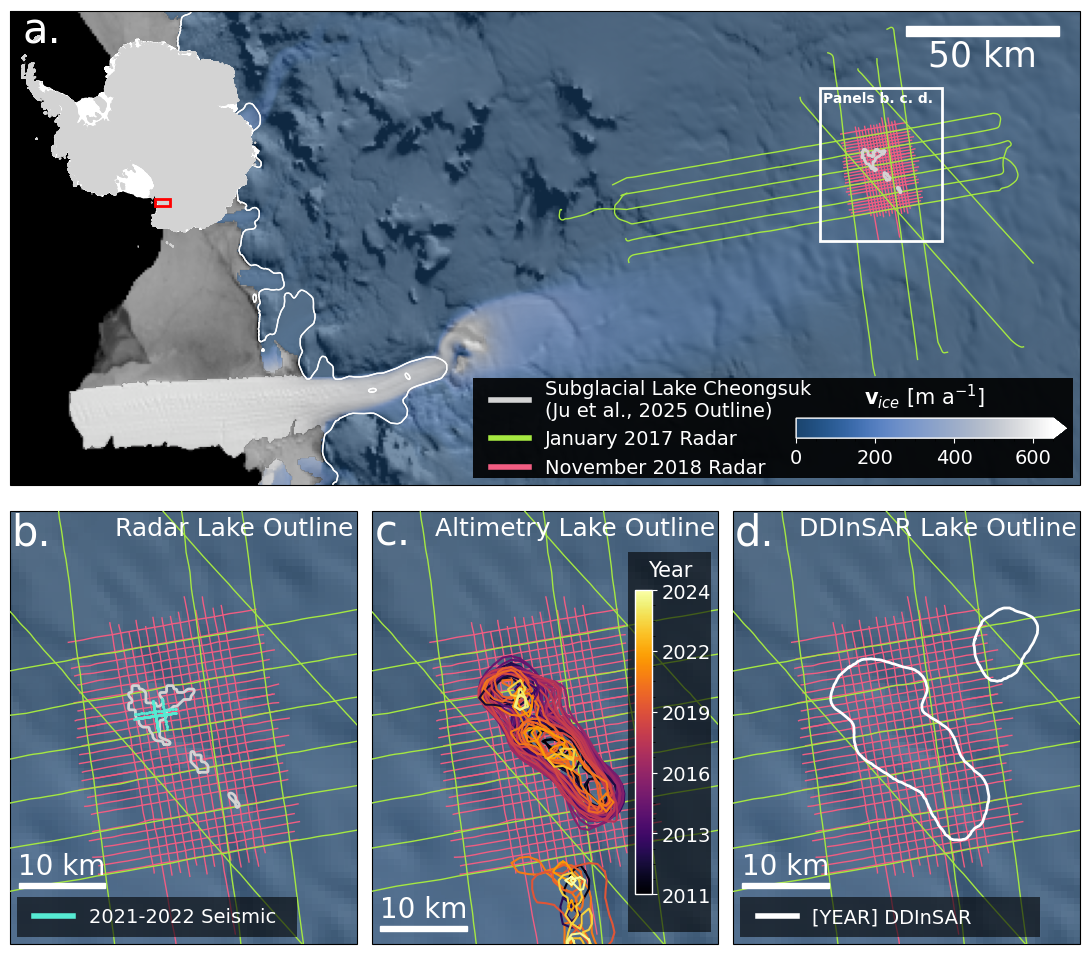

In [12]:
# Plot 4 panel map
lake_color = 'lightgrey'
#[#56ebd3, #f15d82, #a5e841]
_1617color = "#a5e841"
_1819color = '#f15d82'
_seiscolor = '#56ebd3'
bbox = [380000,-1555000,730000,-1400000] #David_SGL2_full
bbox_zoom = [645000,-1475000,685000,-1425000] #David_SGL2
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(11, 10))

gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1])
# Top panel spanning all columns
ax1 = fig.add_subplot(gs[0, :],projection=ps71_projection)
# Bottom three panels
ax2 = fig.add_subplot(gs[1, 0],projection=ps71_projection)
ax3 = fig.add_subplot(gs[1, 1],projection=ps71_projection)
ax4 = fig.add_subplot(gs[1, 2],projection=ps71_projection)


ax1.set_xlim(bbox[0],bbox[2])
ax1.set_ylim(bbox[1],bbox[3])
ax2.set_xlim(bbox_zoom[0],bbox_zoom[2])
ax2.set_ylim(bbox_zoom[1],bbox_zoom[3])
ax3.set_xlim(bbox_zoom[0],bbox_zoom[2])
ax3.set_ylim(bbox_zoom[1],bbox_zoom[3])
ax4.set_xlim(bbox_zoom[0],bbox_zoom[2])
ax4.set_ylim(bbox_zoom[1],bbox_zoom[3])

plt.subplots_adjust(hspace=0.1)
fig.tight_layout()

## Ax1 ##
ax1.imshow(moa_dat, extent=ext, cmap="gray", vmin=12000, vmax=19000)

cb = ax1.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
     vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',vmin=0,vmax=650)

for radargram in offset_video_radargrams_1819:
    ax1.plot(radargram.x, radargram.y, color=_1819color, linewidth=1, zorder=3, transform=ps71_projection)
for radargram in offset_video_radargrams_1617:
    ax1.plot(radargram.x, radargram.y, color=_1617color, linewidth=1, zorder=3, transform=ps71_projection)

#ax1.scatter(seismic['Shot_X'], seismic['Shot_Y'],s=1, c=_seiscolor, label='Seismic Shots', transform=ps71_projection)
ax1.plot(xs[0], ys[0], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
ax1.plot(xs[1], ys[1], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
ax1.plot(xs[2], ys[2], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)

# Legend and Colorbar
k_cbar_anchor = (1,0) # Bottom right of ax1
cbbox = inset_axes(ax1, width=6,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax1.transAxes, loc="lower right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])
cbaxes = inset_axes(cbbox, '45%', '20%', loc = 'right')
cbar = fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
cb.set_alpha(0.6)

cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"$\mathbf{v}_{ice}$ [m a$^{-1}$]", fontsize=15, color='white', labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.minorticks_on()

handles = [
    Line2D([0], [0], color=lake_color, lw=4, label='Subglacial Lake Cheongsuk\n(Ju et al., 2025 Outline)'),
    Line2D([0], [0], color=_1617color, lw=4, label='January 2017 Radar'),
    Line2D([0], [0], color=_1819color, lw=4, label='November 2018 Radar'),
]

# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')

plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax1, colors=['white','None'],
        transform=ps71_projection, fill=False, zorder=2, linewidth=1)

rect = plt.Rectangle(
    (
        bbox_zoom[0],
        bbox_zoom[1],
    ),
    bbox_zoom[2] - bbox_zoom[0],
    bbox_zoom[3] - bbox_zoom[1],
    zorder=3,
    linewidth=2,
    edgecolor="white",
    facecolor="none",
)
ax1.add_patch(rect)
ax1.text(bbox_zoom[0]+1000, bbox_zoom[3]-1000, "Panels b. c. d.",  horizontalalignment="left", verticalalignment="top", fontsize=10, color="white", weight='bold')  

scalebar = AnchoredSizeBar(ax1.transData,
                        50000, '50 km', 'upper right', 
                        pad=0.2,
                        sep=2,
                        color='white',
                        frameon=False,
                        size_vertical=3000,
                        fontproperties=mpl.font_manager.FontProperties(size=25),
                        label_top=False)


ax1.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, 0.99), transform=ax1.transAxes)
    
ax1.text(
    0.03,
    0.96,
    "a.",
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax1.transAxes,
    fontsize=30,
    color="white",
)  

# Add inset map
fig_width, fig_height = fig.get_size_inches()
inset_width_frac = 4 / fig_width
inset_height_frac = 4 / fig_height
bbox_1= ax1.get_position()
# Top-left position of inset
location = [
    bbox_1.x0, 
    bbox_1.y0 + bbox_1.height * 1/2 * 0.95, 
    bbox_1.height * 1/2, 
    bbox_1.height * 1/2
]

inset = fig.add_axes(location, projection=ps71_projection)
inset.patch.set_facecolor("none")
for spine in inset.spines.values():
    spine.set_visible(False)
inset.set_xticks([])
inset.set_yticks([])

# Plot map of Antarctica
plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
        transform=ps71_projection, fill=True, zorder=2, linewidth=1)

rect = plt.Rectangle(
    (
        bbox[0],
        bbox[1],
    ),
    bbox[2] - bbox[0],
    bbox[3] - bbox[1],
    zorder=3,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
inset.add_patch(rect)


## AX2 ##
ax2.imshow(moa_dat, extent=ext, cmap="gray", vmin=12000, vmax=19000)
ax2.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
     vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',vmin=0,vmax=650,alpha=0.6)

# Radar, lake, seismic
# Radar, Seismic, Sauthoff Lake Extent
for radargram in offset_video_radargrams_1819:
    ax2.plot(radargram.x, radargram.y, color=_1819color, linewidth=1, zorder=3, transform=ps71_projection)
for radargram in offset_video_radargrams_1617:
    ax2.plot(radargram.x, radargram.y, color=_1617color, linewidth=1, zorder=3, transform=ps71_projection)

ax2.scatter(seismic['Shot_X'], seismic['Shot_Y'],s=1, c=_seiscolor, label='Seismic Shots', transform=ps71_projection,zorder=10)
ax2.plot(xs[0], ys[0], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
ax2.plot(xs[1], ys[1], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
ax2.plot(xs[2], ys[2], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)

scalebar = AnchoredSizeBar(ax2.transData,
                        10000, '10 km', 'lower left', 
                        pad=0.2,
                        sep=2,
                        color='white',
                        frameon=False,
                        size_vertical=600,
                        fontproperties=mpl.font_manager.FontProperties(size=20),
                        label_top=True)


ax2.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.0, 0.11), transform=ax2.transAxes)

ax2.text(
    0.06,
    0.95,
    "b.",
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax2.transAxes,
    fontsize=30,
    color="white",
)  
ax2.text(
    0.99,
    0.96,
    "Radar Lake Outline",
    horizontalalignment="right",
    verticalalignment="center",
    transform=ax2.transAxes,
    fontsize=18,
    color="white",
)  

k_cbar_anchor = (0,0) # Bottom right of ax1
cbbox = inset_axes(ax2, width=2.8,height=0.4,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax2.transAxes, loc="lower left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.6])
handles = [
    Line2D([0], [0], color=_seiscolor, lw=4, label='2021-2022 Seismic'),
]

# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')


## AX3 ##
# Evolving Outline
ax3.imshow(moa_dat, extent=ext, cmap="gray", vmin=12000, vmax=19000)
ax3.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
     vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',vmin=0,vmax=650,alpha=0.6)

times = evolving_outlines["mid_pt_datetime"]

# Convert datetimes → numeric (float seconds)
t_num = np.array(times.astype("int64"))  # nanoseconds since epoch

# Normalize to 0–1 range for the colormap
norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
cmap = cm.get_cmap("inferno")

for radargram in offset_video_radargrams_1819:
    ax3.plot(radargram.x, radargram.y, color=_1819color, linewidth=1, zorder=3, transform=ps71_projection)
for radargram in offset_video_radargrams_1617:
    ax3.plot(radargram.x, radargram.y, color=_1617color, linewidth=1, zorder=3, transform=ps71_projection)


for outline, time in zip(evolving_outlines['geometry'], t_num):
    x_evolve, y_evolve = outline.exterior.xy
    color = cmap(norm(time))
    ax3.plot(x_evolve, y_evolve, color=color,zorder=5)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Radar, Seismic, Sauthoff Lake Extent
scalebar = AnchoredSizeBar(ax3.transData,
                        10000, '10 km', 'lower left', 
                        pad=0.2,
                        sep=2,
                        color='white',
                        frameon=False,
                        size_vertical=600,
                        fontproperties=mpl.font_manager.FontProperties(size=20),
                        label_top=True)


ax3.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.0, 0.01), transform=ax3.transAxes)

ax3.text(
    0.06,
    0.95,
    "c.",
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax3.transAxes,
    fontsize=30,
    color="white",
)  
ax3.text(
    0.99,
    0.96,
    "Altimetry Lake Outline",
    horizontalalignment="right",
    verticalalignment="center",
    transform=ax3.transAxes,
    fontsize=18,
    color="white",
)  

k_cbar_anchor = (1,0.92) # Bottom right of ax1
cbbox = inset_axes(ax3, width=0.83,height=3.8,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax3.transAxes, loc="upper right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.6])
cbaxes = inset_axes(cbbox, '20%', '80%', loc = 'center left')
cbar = fig.colorbar(sm,cax=cbaxes, orientation='vertical') #make colorbar

tick_nums = np.linspace(t_num.min(), t_num.max(), 6)
tick_dates = pd.to_datetime(tick_nums, unit='ms')     # convert to datetime
tick_years = tick_dates.year                # extract just year

cbar.set_ticks(tick_nums)
cbar.set_ticklabels(tick_years,fontsize=20, color='white')

cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
#cbar.set_label("Year", fontsize=15, color='red', labelpad=0)
#cbar.ax.set_title("Year", fontsize=15, color='white')
cbar.ax.minorticks_on()

# Add legend directly to cbbox
cbar_label = cbbox.text(0.5, 0.98, 'Year', transform=cbbox.transAxes, fontsize=15, color='white', ha='center', va='top')


## Ax 4 ##
#DDInSAR Outlines
ax4.imshow(moa_dat, extent=ext, cmap="gray", vmin=12000, vmax=19000)
ax4.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
     vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',vmin=0,vmax=650,alpha=0.6)

for radargram in offset_video_radargrams_1819:
    ax4.plot(radargram.x, radargram.y, color=_1819color, linewidth=1, zorder=3, transform=ps71_projection)
for radargram in offset_video_radargrams_1617:
    ax4.plot(radargram.x, radargram.y, color=_1617color, linewidth=1, zorder=3, transform=ps71_projection)


# DDInSAR Outlines
for outline in DDInSAR_outlines:
    x_DDInSAR, y_DDInSAR = outline
    ax4.plot(x_DDInSAR, y_DDInSAR, color='white', linewidth=2, zorder=3, transform=ps71_projection)

scalebar = AnchoredSizeBar(ax4.transData,
                        10000, '10 km', 'lower left', 
                        pad=0.2,
                        sep=2,
                        color='white',
                        frameon=False,
                        size_vertical=600,
                        fontproperties=mpl.font_manager.FontProperties(size=20),
                        label_top=True)


ax4.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.0, 0.11), transform=ax4.transAxes)

ax4.text(
    0.06,
    0.95,
    "d.",
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax4.transAxes,
    fontsize=30,
    color="white",
)  
ax4.text(
    0.99,
    0.96,
    "DDInSAR Lake Outline",
    horizontalalignment="right",
    verticalalignment="center",
    transform=ax4.transAxes,
    fontsize=18,
    color="white",
)  

k_cbar_anchor = (0,0) # Bottom right of ax1
cbbox = inset_axes(ax4, width=3,height=0.4,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax4.transAxes, loc="lower left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.6])
handles = [
    Line2D([0], [0], color='white', lw=4, label='[YEAR] DDInSAR'),
]

# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')

plt.savefig('./Figure1.png', dpi=300, bbox_inches='tight')